In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')  # so the notebook can find src/
from src.time_series import fetch_returns, fit_garch, forecast_volatility

/Users/basava/Documents/git/Claude_finance/bs_pricer/.claude_finance/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Downloading Data

Using `fetch_returns`, extracting the returns of 3 years of data.

In [2]:

# fetch SPY returns
returns = fetch_returns("SPY", period="3y")
print(f"Returns shape: {returns.shape}")
print(f"Mean: {returns.mean():.4f}%")
print(f"Std: {returns.std():.4f}%")
print(returns.tail())

[*********************100%***********************]  1 of 1 completed

Returns shape: (752,)
Mean: 0.0834%
Std: 0.9510%
Date
2026-05-11    0.227500
2026-05-12   -0.151609
2026-05-13    0.557926
2026-05-14    0.786326
2026-05-15   -1.210229
Name: SPY, dtype: float64


### Fit GARCH Model

Fitting the GARCH(1,1) model is performed using the `fit_garch` method. GARCH models volatility, and specifically within the GARCH(1,1) framework, the variance equation is expressed as:

$$\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

*   **$\omega$ (Long-Run Baseline Variance)**

    This coefficient represents the baseline variance floor that the model reverts to when other factors are zero. It is mathematically related to the long-run average variance by the formula:
    $$\bar{\sigma}^2 = \frac{\omega}{1 - \alpha - \beta}$$

*   **$\alpha$ (Reaction Coefficient)**

    This parameter measures the intensity of today's volatility reaction to yesterday's shock, $\epsilon^2_{t-1}$. A high $\alpha$ value indicates that volatility will spike rapidly following a large return. This represents the "news impact," quantifying how much an unexpected market movement influences subsequent volatility.

*   **$\beta$ (Persistence Coefficient)**

    This coefficient captures how much of yesterday's volatility carries over into today. A high $\beta$ value means that volatility decays slowly after a spike, exhibiting stickiness. This persistence is the underlying mechanism that generates the volatility clustering effect.

In [3]:
garch_results = fit_garch(returns, p=1, q=1, dist='normal')

print(f"omega: {garch_results['omega']:.6f}")
print(f"alpha: {garch_results['alpha']:.4f}")
print(f"beta:  {garch_results['beta']:.4f}")
print(f"alpha + beta: {garch_results['alpha'] + garch_results['beta']:.4f}")
print(f"AIC: {garch_results['aic']:.2f}")

# long run volatility
omega = garch_results['omega']
alpha = garch_results['alpha']
beta  = garch_results['beta']
long_run_var = omega / (1 - alpha - beta)
long_run_vol = np.sqrt(long_run_var) / 100
print(f"\nLong-run daily vol: {long_run_vol:.4f}")
print(f"Long-run annualised vol: {long_run_vol * np.sqrt(252):.4f}")

# half life
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Volatility half-life: {half_life:.1f} days")

omega: 0.054836
alpha: 0.1059
beta:  0.8236
alpha + beta: 0.9295
AIC: 1867.75

Long-run daily vol: 0.0088
Long-run annualised vol: 0.1400
Volatility half-life: 9.5 days


**What the Parameters Tell**

*   **`alpha = 0.106` (Moderate Reaction)**

    When a significant return shock occurs, approximately 10.5% of its impact directly feeds into the variance of the following day. This indicates a meaningful, though not extreme, response to new information.

*   **`beta = 0.824` (High Persistence)**

    About 82.5% of the prior day's variance carries forward, showing that volatility is highly persistent and sticky.

*   **`alpha + beta = 0.930` (Stationary)**

    Because this sum is well below 1, the model confirms that variance is stable and exhibits mean-reverting behavior.

*   **`Long-run annualized vol = 14.0%`**

    This value represents the long-run average volatility for SPY as implied by the model. Given that SPY historically averages between 15% and 18%, a baseline of 14% is a reasonable estimate.

* **The Half-Life is Short**

    A half-life of 9.6 days represents a very rapid rate of mean reversion.

GARCH(1,1) model using a normal distribution (`dist='normal'`) can underestimate persistence by failing to account for fat tails. Under a normal distribution assumption, the model is forced to attribute extreme returns to heightened variance rather than heavy tails, which can skew parameter estimations. 

Consequently, using a Student's t-distribution (`dist='t'`) is a more suitable choice for modeling the distribution of financial returns.

In [4]:
garch_t = fit_garch(returns, p=1, q=1, dist='t')

print("Normal distribution:")
print(f"  alpha={garch_results['alpha']:.4f}, beta={garch_results['beta']:.4f}")
print(f"  alpha+beta={garch_results['alpha']+garch_results['beta']:.4f}")
print(f"  AIC={garch_results['aic']:.2f}")

print("\nStudent-t distribution:")
print(f"  alpha={garch_t['alpha']:.4f}, beta={garch_t['beta']:.4f}")
print(f"  alpha+beta={garch_t['alpha']+garch_t['beta']:.4f}")
print(f"  AIC={garch_t['aic']:.2f}")

half_life_t = np.log(0.5) / np.log(garch_t['alpha'] + garch_t['beta'])
print(f"Volatility half-life: {half_life_t:.1f} days")

Normal distribution:
  alpha=0.1059, beta=0.8236
  alpha+beta=0.9295
  AIC=1867.75

Student-t distribution:
  alpha=0.1014, beta=0.8180
  alpha+beta=0.9193
  AIC=1814.52
Volatility half-life: 8.2 days


*   **AIC: 1867 $\rightarrow$ 1814**

    A reduction of 53 points is achieved. In statistical model selection, any difference greater than 10 is considered decisive, confirming that the Student's t-distribution fits SPY returns significantly better than the normal distribution. This validates the theoretical understanding that equity returns exhibit fat tails which a normal distribution cannot adequately capture.

*   **alpha + beta: 0.9295 $\rightarrow$ 0.9193**

    The model shows slightly lower persistence under the Student's t-distribution. When fat tails are modeled properly, the variance process requires less adjustment to account for extreme market movements, as some of that extremity is instead attributed directly to the heavy-tailed nature of the distribution.

*   **Stable Parameters**

    The underlying structure of the model remains robust, as both alpha (0.105 $\rightarrow$ 0.101) and beta (0.824 $\rightarrow$ 0.818) barely changed despite the modification to the distributional assumption.

## Forecasting

In [5]:
# use the t-distribution model
fitted_result = garch_t['result']

# forecast 22 days ahead (1 trading month)
vol_forecast = forecast_volatility(fitted_result, horizon=22)
print(f"Volatility forecast shape: {vol_forecast.shape}")
print(f"1-day ahead vol:  {vol_forecast[0]:.4f} ({vol_forecast[0]*np.sqrt(252):.2%} annualised)")
print(f"22-day ahead vol: {vol_forecast[-1]:.4f} ({vol_forecast[-1]*np.sqrt(252):.2%} annualised)")

Volatility forecast shape: (22,)
1-day ahead vol:  0.0082 (13.06% annualised)
22-day ahead vol: 0.0086 (13.73% annualised)


This reveals an important insight about the current state of the market. GARCH forecasts are designed to mean-revert toward long-run volatility, with the direction of the trend determined by where current volatility stands relative to that long-run average:

*   **Current Volatility > Long-Run Volatility:** The forecast decays downward.
*   **Current Volatility < Long-Run Volatility:** The forecast rises upward.

In this case, the long-run annualized volatility is 14.0%, while the current 1-day volatility sits at 13.46%. Because the current level is slightly below the long-run average, the model forecasts a gentle upward trajectory back toward 14%.

This trend may seem unexpected given the large daily swings recently observed in the returns data. However, the GARCH model indicates that the current period—despite its visible volatility—is actually tracking slightly below its own long-run average. This average is calculated from three years of historical data, which encompasses the highly volatile 2022–2023 period.

### Visualization

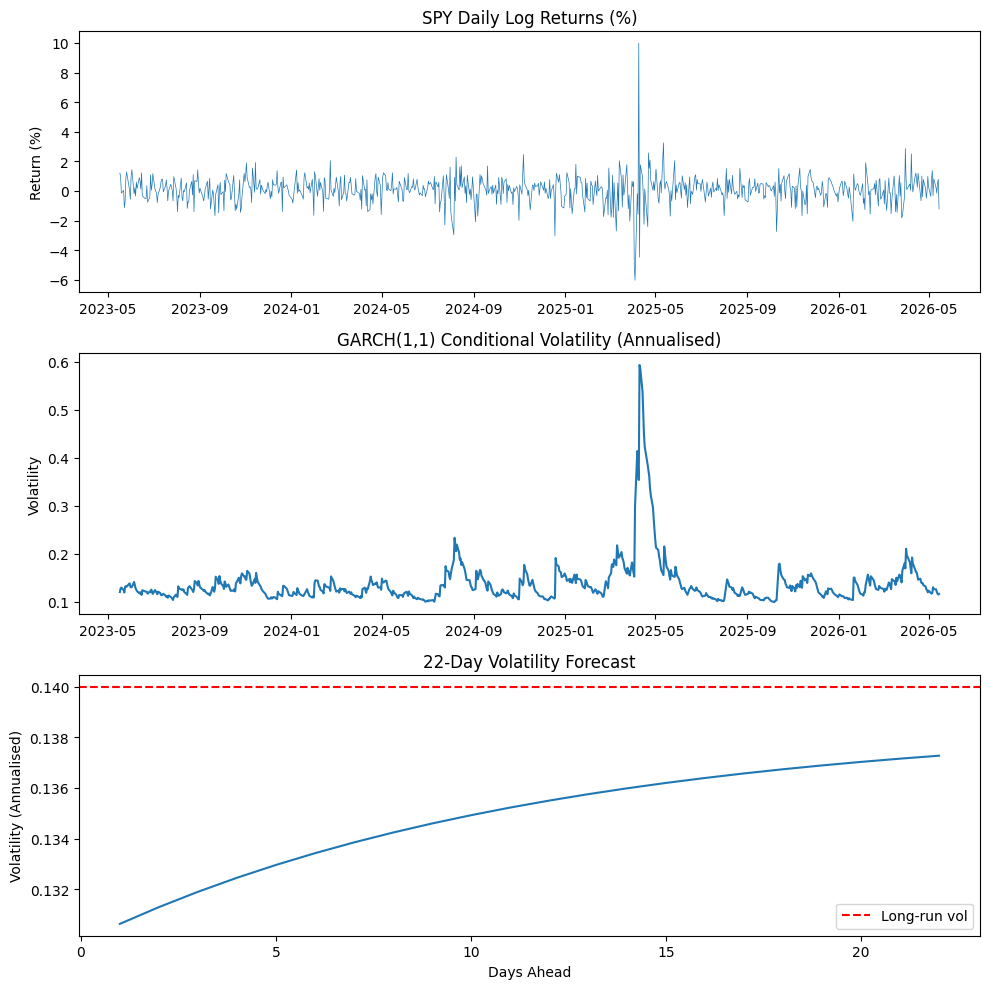

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

axes[0].plot(returns.index, returns.values, linewidth=0.5)
axes[0].set_title('SPY Daily Log Returns (%)')
axes[0].set_ylabel('Return (%)')


cond_vol = fitted_result.conditional_volatility
axes[1].plot(cond_vol.index, cond_vol.values / 100 * np.sqrt(252))
axes[1].set_title('GARCH(1,1) Conditional Volatility (Annualised)')
axes[1].set_ylabel('Volatility')

days_ahead = np.arange(1, 23)
axes[2].plot(days_ahead, vol_forecast * np.sqrt(252))
axes[2].axhline(long_run_vol * np.sqrt(252), linestyle='--', color='red', label='Long-run vol')
axes[2].set_title('22-Day Volatility Forecast')
axes[2].set_xlabel('Days Ahead')
axes[2].set_ylabel('Volatility (Annualised)')
axes[2].legend()

plt.tight_layout()
plt.savefig("../results/04_garch_forecast.png", dpi=150)

**Plot 1 — Returns**

* Volatility clustering is clearly visible across the timeline. The period around early 2025 exhibits a dramatic spike, featuring returns of +10% and -6% in quick succession. Before and after this specific episode, the market is much calmer, with standard swings of ±2%. This behavior represents textbook clustering, where large price movements tend to be followed by large price movements. 

* This particular spike in early 2025 was primarily driven by the lingering effects of massive U.S. tariff announcements made in April, combined with renewed concerns over U.S. fiscal health and escalating geopolitical tensions.

**Plot 2 — Conditional Volatility**

* The GARCH model captures this volatility clustering precisely. The early 2025 shock pushes annualized volatility to nearly 0.60—an extreme 60% annualized level for SPY. Following the spike, the volatility decays rapidly, aligning with the calculated 8.6-day half-life. By mid-2025, volatility drops back down to the 0.10–0.15 range. 
* Throughout 2023 and 2024, the baseline volatility remains remarkably stable at 0.10–0.15, marking a highly tranquil period prior to the 2025 spike, which is followed by a partial recovery accompanied by increased noise in 2026.

**Plot 3 — Forecast**

* The forecast trajectory rises toward the red dashed long-run line, which confirms that current volatility is sitting slightly below the long-run average. The resulting curve is concave, displaying a rapid initial ascent that tapers off over time. This illustrates the expected mean reversion dynamic. 
* The forecast has not fully converged by day 22, which is consistent with the 8.6-day half-life, as a full convergence naturally requires multiple half-life periods.